# ***IBM HR Analytics Employee Attrition & Performance***

Import Libraries

In [133]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


Load dataset

In [134]:
# Load dataset
# -----------------------------------------

df = pd.read_csv('../dataset/dataset.csv')

print(df.sample(5))

      Age Attrition     BusinessTravel  DailyRate              Department  \
511    36        No      Travel_Rarely        913  Research & Development   
1440   36        No  Travel_Frequently        688  Research & Development   
1063   29        No      Travel_Rarely       1246                   Sales   
1197   20        No      Travel_Rarely        727                   Sales   
1073   28        No      Travel_Rarely       1083  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
511                  9          2        Medical              1   
1440                 4          2  Life Sciences              1   
1063                19          3  Life Sciences              1   
1197                 9          1  Life Sciences              1   
1073                29          1  Life Sciences              1   

      EmployeeNumber  ...  RelationshipSatisfaction StandardHours  \
511              699  ...                         3            80

In [135]:
# Shape of df
print(df.shape)

# df columns
print(df.columns)

(1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [136]:
# Description of the dataframe
# -------------------------------------------

print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [137]:
# Show dataframe information 
# ---------------------------------------------

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [138]:
# Check duplicate and Null Value
# -----------------------------------------------


print('Check Duplicate :\n',df.duplicated().sum()) # check duplicate

print('-'*200)

print('Check Null Values: \n', df.isnull().sum()) # check Null values

Check Duplicate :
 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Check Null Values: 
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
Relatio

# Feature Selection 

In [139]:
# print(df.sample(3))

Identify single value columns

In [140]:
# Identify Single value Columns

single_val_col = []
for col in df.columns:
    if(len(df[col].unique()) == 1): 
        single_val_col.append(col)
print(single_val_col)




['EmployeeCount', 'Over18', 'StandardHours']


In [141]:
# Feature Selection 
# -------------------------------------------------

# drop a single value columns
df = df.drop(columns = single_val_col)


print(len(df.columns))


# Also delete employee number columns(Not required to train a model)
df = df.drop(columns = ['EmployeeNumber'])
print(df)


32
      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSatisfactio

In [142]:
# print(df.info())

**Correlation Matrix for Numerical Columns**

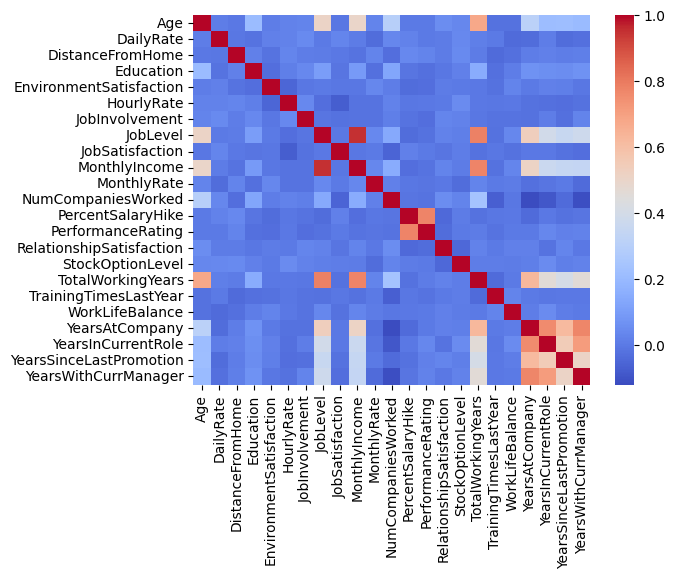

In [143]:
# Correlation Matrix
# -------------------------------------------


corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=False,
            cmap='coolwarm')
plt.show()

**Encoding Categorical to numerical column**

In [144]:
# ======================================================
# Categorical Feature Encoding
# ======================================================

# Binary Categorical Feature (Label Encoding)
# ------------------------------------------------------
# 1. Gender      : Female, Male
# 2. Attrition   : Yes, No (Target Variable)
# 3. OverTime    : Yes, No

binary_columns = ['Attrition', 'Gender', 'OverTime']


# Nominal Categorical Feature (One hot Encoding)
# ------------------------------------------------------
# 1. BusinessTravel     : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
# 2. Department         : ['Sales' 'Research & Development' 'Human Resources']
# 3. EducationField     : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree' 'Human Resources']
# 4. JobRole            : ['Sales Executive' 'Research Scientist' 'Laboratory Technician' 'Manufacturing Director' 'Healthcare Representative' 'Manager''Sales Representative' 'Research Director' 'Human Resources']
# 5. MaritalStatus      : ['Single' 'Married' 'Divorced']


Ont_hot_Encoding_columns = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'MaritalStatus',
    'JobRole'
]


In [145]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Binary Encoding  (Label Encoding)

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

print(df.sample(4))

     Age  Attrition     BusinessTravel  DailyRate              Department  \
132   31          1      Travel_Rarely        542                   Sales   
351   32          0      Travel_Rarely       1062  Research & Development   
119   43          0  Travel_Frequently        394                   Sales   
108   25          0      Travel_Rarely       1280  Research & Development   

     DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
132                20          3  Life Sciences                        2   
351                 2          3        Medical                        3   
119                26          2  Life Sciences                        3   
108                 7          1        Medical                        4   

     Gender  ...  PerformanceRating  RelationshipSatisfaction  \
132       0  ...                  3                         3   
351       0  ...                  3                         3   
119       1  ...                  3   

In [146]:
# One hot encoding

df = pd.get_dummies(
    df, 
    columns=Ont_hot_Encoding_columns,
    drop_first=True,
    dtype=int
)

print(df.sample(5))

      Age  Attrition  DailyRate  DistanceFromHome  Education  \
275    37          0        728                 1          4   
1396   53          1       1168                24          4   
1405   31          0        697                10          3   
392    54          0        821                 5          2   
921    28          0        791                 1          4   

      EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  \
275                         1       0          80               3         3   
1396                        1       1          66               3         3   
1405                        3       0          40               3         3   
392                         1       1          86               3         5   
921                         4       1          44               3         1   

      ...  MaritalStatus_Married  MaritalStatus_Single  \
275   ...                      0                     0   
1396  ...               

In [152]:
# print(df.columns)

**Split the dataset**

In [153]:
# Splitting a dataset
from sklearn.model_selection import train_test_split
# print(df.head(2))
X = df.drop(columns=['Attrition'])
Y = df['Attrition']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [157]:
# print(X_train.sample(5))

print(X_train.shape)

(1176, 44)


# **Feature Scaling**

In [161]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# print(X_train_scaled)

In [169]:
# Model where Feature scaling require
# -------------------------------------------------------
# SVM, 
# KNN, 
# K Mean Clustering, 
# Deep Learning 
# -------------------------------------------------------

# ======================================================= 


from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier



svm = SVC()
knn = KNeighborsClassifier()

# Train SVM 
svm.fit(X_train_scaled, Y_train)
y_pred_svm = svm.predict(X_test_scaled)

# Train KNN
knn.fit(X_train_scaled, Y_train)
y_pred_knn = knn.predict(X_test_scaled)



In [177]:
# Model where No Feature scaling require
# -------------------------------------------------------
# Logistic Regression
# Random Forest Classifier  
# Decision Tree
# XG Boost
# -------------------------------------------------------

# ======================================================= 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



lr  = LogisticRegression()
rf = RandomForestClassifier(
    n_estimators=200,
)
dt = DecisionTreeClassifier()

# Linear Regressor train
lr.fit(X_train_scaled, Y_train)
y_pred_lr = lr.predict(X_test_scaled)

# decision tree train
dt.fit(X_train, Y_train)
y_pred_dt = dt.predict(X_test)

# random forest classifier train
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)



In [178]:
# Calculate the Metrics

from sklearn.metrics import accuracy_score, f1_score, precision_score

print(f'SVM Accuracy: {accuracy_score(Y_test, y_pred_svm)}')
print(f'KNN Accuracy: {accuracy_score(Y_test, y_pred_knn)}')
print(f'Logistic Regression Accuracy: {accuracy_score(Y_test, y_pred_lr)}')
print(f'Decision Tree Accuracy: {accuracy_score(Y_test, y_pred_dt)}')
print(f'Random Forest Accuracy: {accuracy_score(Y_test, y_pred_rf)}')

print('-'*200)

print(f'SVM precision: {precision_score(Y_test, y_pred_svm)}')
print(f'KNN precision: {precision_score(Y_test, y_pred_knn)}')
print(f'Logistic Regression precision: {precision_score(Y_test, y_pred_lr)}')
print(f'Decision Tree precision: {precision_score(Y_test, y_pred_dt)}')
print(f'Random Forest precision: {precision_score(Y_test, y_pred_rf)}')

print('-'*200)

print(f'SVM F1 Score: {f1_score(Y_test, y_pred_svm)}')
print(f'KNN F1 Score: {f1_score(Y_test, y_pred_knn)}')
print(f'Logistic Regression F1 Score: {f1_score(Y_test, y_pred_lr)}')
print(f'Decision Tree F1 Score: {f1_score(Y_test, y_pred_dt)}')
print(f'Random Forest F1 Score: {f1_score(Y_test, y_pred_rf)}')

SVM Accuracy: 0.8979591836734694
KNN Accuracy: 0.8809523809523809
Logistic Regression Accuracy: 0.8775510204081632
Decision Tree Accuracy: 0.7517006802721088
Random Forest Accuracy: 0.8809523809523809
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
SVM precision: 0.9090909090909091
KNN precision: 0.7
Logistic Regression precision: 0.5483870967741935
Decision Tree precision: 0.14583333333333334
Random Forest precision: 1.0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
SVM F1 Score: 0.4
KNN F1 Score: 0.2857142857142857
Logistic Regression F1 Score: 0.4857142857142857
Decision Tree F1 Score: 0.16091954022988506
Random Forest F1 Score: 0.18604651162790697
